In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [9]:
# Download data — multi-asset universe
tickers = {"SPY": "S&P 500", "QQQ": "Nasdaq 100", "GLD": "Gold", "BND": "Bonds"}

prices = {}
for ticker, name in tickers.items():
    raw = yf.download(ticker, start="2015-01-01", end="2024-12-31", progress=False)
    prices[ticker] = raw["Close"].squeeze()
    print(f"{name} ({ticker}): {len(prices[ticker])} days loaded")

S&P 500 (SPY): 2515 days loaded
Nasdaq 100 (QQQ): 2515 days loaded
Gold (GLD): 2515 days loaded
Bonds (BND): 2515 days loaded


In [10]:
# Momentum signal & backtest — all assets
lookback = 252  # 12-month momentum window

results = {}

for ticker, name in tickers.items():
    px = prices[ticker]
    
    # Daily returns
    daily_ret = px.pct_change()
    
    # Momentum signal: 1 = long, 0 = cash
    signal = (px.pct_change(lookback) > 0).astype(int)
    
    # Strategy returns (shift by 1 to avoid look-ahead bias)
    strat_ret = daily_ret * signal.shift(1)
    
    # Cumulative performance (base 100)
    cum_strat = (1 + strat_ret).cumprod() * 100
    cum_bh    = (1 + daily_ret).cumprod() * 100
    
    results[ticker] = {
        "name":      name,
        "cum_strat": cum_strat.dropna(),
        "cum_bh":    cum_bh.dropna(),
        "strat_ret": strat_ret.dropna(),
        "daily_ret": daily_ret.dropna(),
        "signal":    signal,
    }

print("Backtest computed for all assets.")

Backtest computed for all assets.


In [11]:
# Performance metrics
def sharpe_ratio(returns, risk_free=0.02):
    excess = returns - risk_free / 252
    return np.sqrt(252) * excess.mean() / excess.std()

def max_drawdown(cumulative):
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

def annualized_return(cumulative):
    n_years = len(cumulative) / 252
    return (cumulative.iloc[-1] / cumulative.iloc[0]) ** (1 / n_years) - 1

# Print results table
print(f"{'Asset':<14} {'Strat Ret':>10} {'B&H Ret':>10} {'Sharpe':>8} {'Max DD':>10} {'In Mkt':>8}")
print("=" * 65)

for ticker, r in results.items():
    ann_ret  = annualized_return(r["cum_strat"])
    bh_ret   = annualized_return(r["cum_bh"])
    sharpe   = sharpe_ratio(r["strat_ret"])
    mdd      = max_drawdown(r["cum_strat"])
    in_mkt   = r["signal"].mean()
    
    print(f"{r['name']:<14} {ann_ret:>10.1%} {bh_ret:>10.1%} {sharpe:>8.2f} {mdd:>10.1%} {in_mkt:>8.0%}")

Asset           Strat Ret    B&H Ret   Sharpe     Max DD   In Mkt
S&P 500              8.4%      13.3%     0.53     -31.2%      75%
Nasdaq 100          12.7%      18.6%     0.64     -31.2%      76%
Gold                 2.9%       7.6%     0.13     -33.3%      62%
Bonds                1.9%       1.4%     0.00      -8.7%      57%


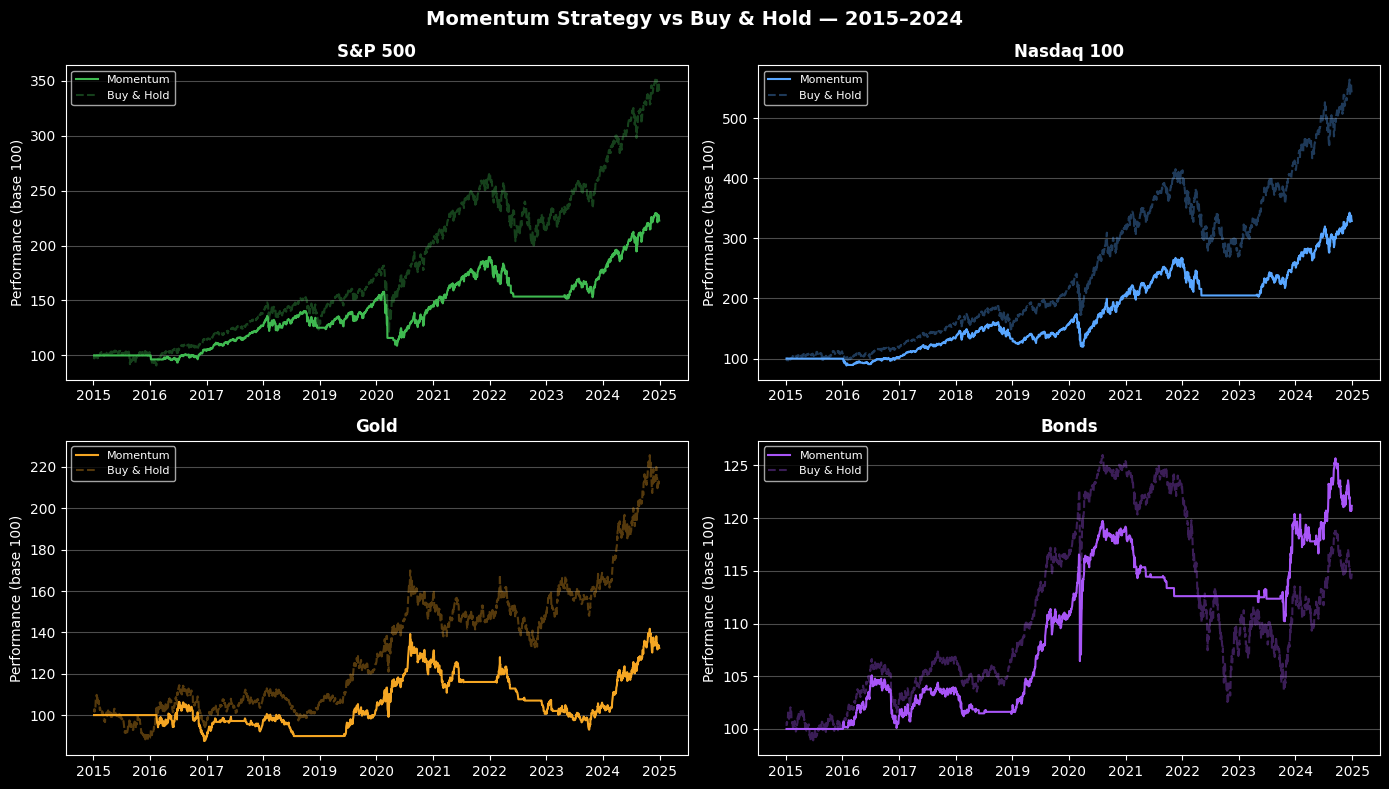

Chart saved.


In [12]:
# Performance chart — all assets
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors = {"SPY": "#3fb950", "QQQ": "#58a6ff", "GLD": "#f5a623", "BND": "#a855f7"}

for i, (ticker, r) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(r["cum_strat"].index, r["cum_strat"],
            color=colors[ticker], linewidth=1.5, label="Momentum")
    ax.plot(r["cum_bh"].index, r["cum_bh"],
            color=colors[ticker], linewidth=1.5, alpha=0.35, linestyle="--", label="Buy & Hold")
    ax.set_title(r["name"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Performance (base 100)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Momentum Strategy vs Buy & Hold — 2015–2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("assets/performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

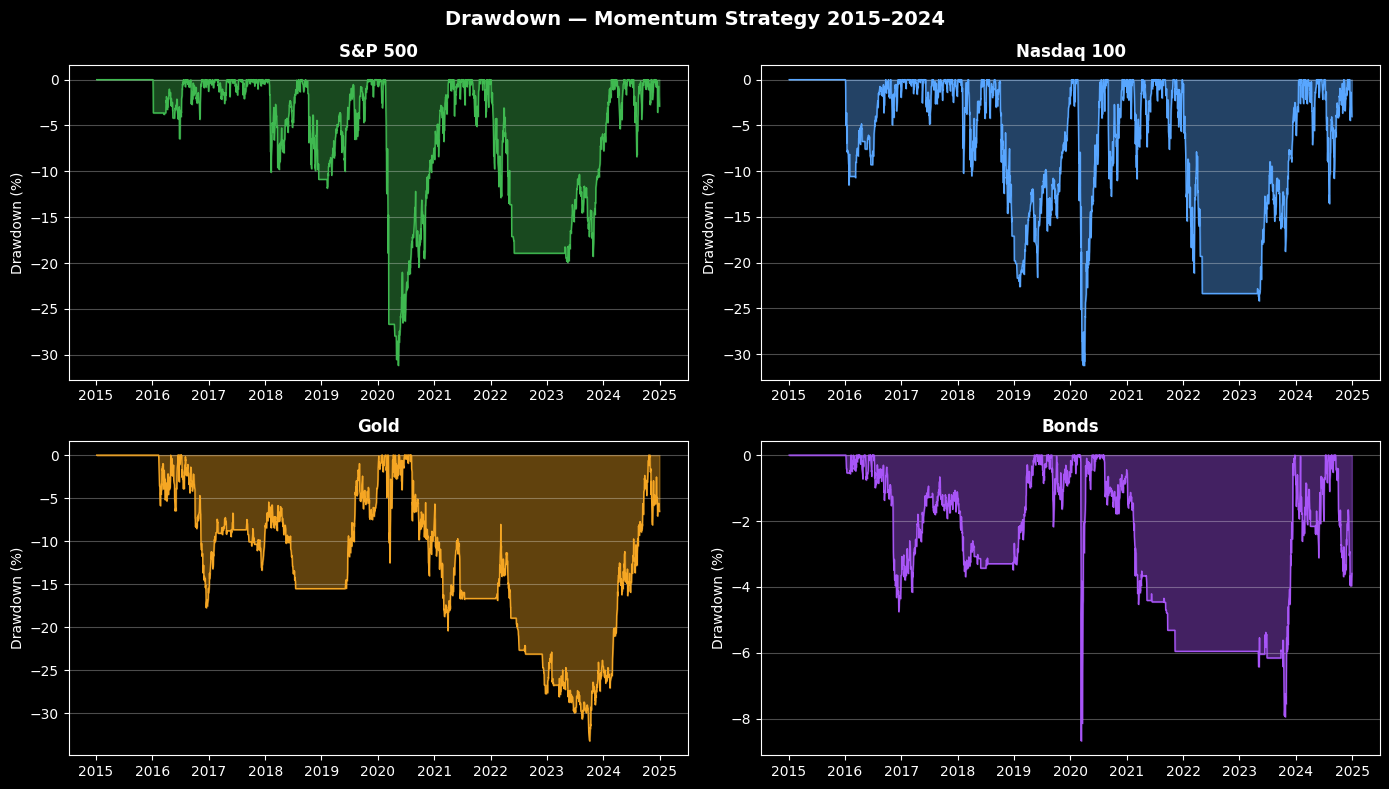

Drawdown chart saved.


In [13]:
# Dynamic drawdown chart — all assets
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (ticker, r) in enumerate(results.items()):
    ax = axes[i]
    
    cum = r["cum_strat"]
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max * 100
    
    ax.fill_between(drawdown.index, drawdown, 0,
                    color=colors[ticker], alpha=0.4)
    ax.plot(drawdown.index, drawdown,
            color=colors[ticker], linewidth=1)
    ax.set_title(r["name"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Drawdown (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Drawdown — Momentum Strategy 2015–2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("assets/drawdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Drawdown chart saved.")

Window        Ann. Return   Sharpe     Max DD  In Market
3 months             6.8%     0.46     -23.7%        74%
6 months             7.6%     0.51     -23.3%        75%
12 months            8.4%     0.53     -31.2%        75%


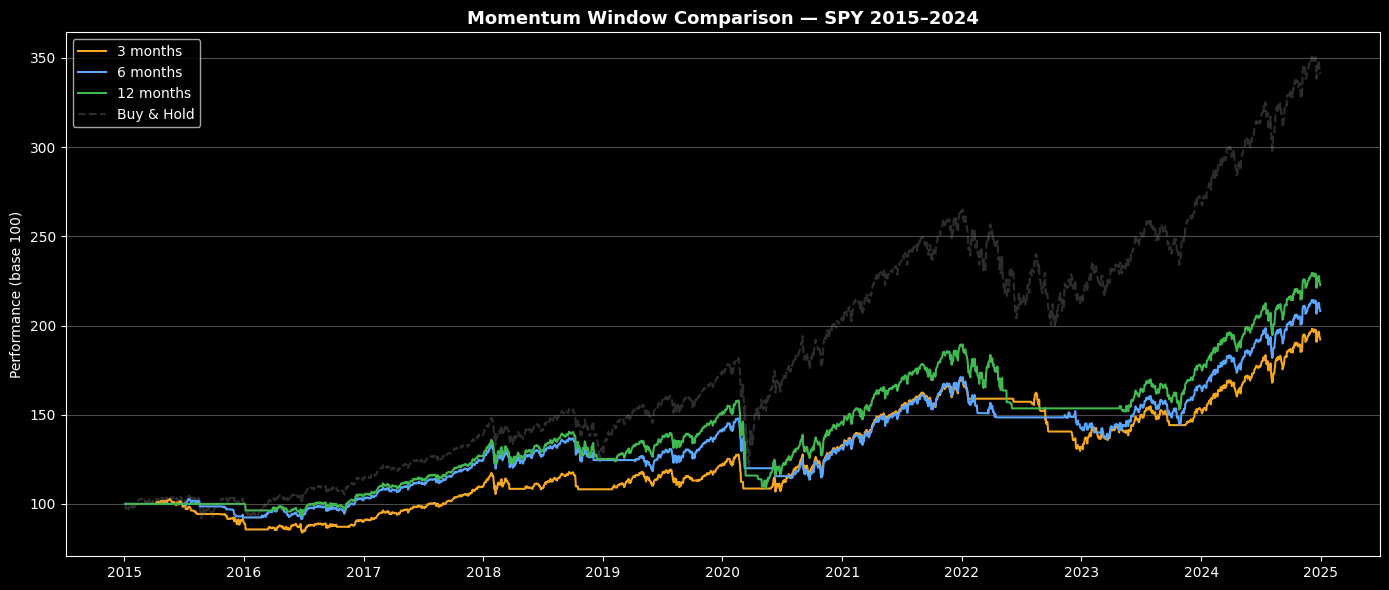


Chart saved.


In [15]:
# Momentum window analysis — SPY
windows = {
    "3 months":  63,
    "6 months":  126,
    "12 months": 252,
}

px = prices["SPY"]
daily_ret = px.pct_change()

fig, ax = plt.subplots(figsize=(14, 6))

window_colors = {"3 months": "#f5a623", "6 months": "#58a6ff", "12 months": "#3fb950"}

print(f"{'Window':<12} {'Ann. Return':>12} {'Sharpe':>8} {'Max DD':>10} {'In Market':>10}")
print("=" * 55)

for label, lookback in windows.items():
    signal   = (px.pct_change(lookback) > 0).astype(int)
    strat_ret = daily_ret * signal.shift(1)
    cum      = (1 + strat_ret).cumprod() * 100
    cum      = cum.dropna()
    
    ax.plot(cum.index, cum, linewidth=1.5,
            color=window_colors[label], label=label)
    
    print(f"{label:<12} {annualized_return(cum):>12.1%} "
          f"{sharpe_ratio(strat_ret.dropna()):>8.2f} "
          f"{max_drawdown(cum):>10.1%} "
          f"{signal.mean():>10.0%}")

# Buy & Hold reference
cum_bh_clean = cum_bh.dropna()
ax.plot(cum_bh_clean.index, cum_bh_clean,
        linewidth=1.5, alpha=0.35, linestyle="--",
        color="gray", label="Buy & Hold")

ax.set_title("Momentum Window Comparison — SPY 2015–2024", fontsize=13, fontweight="bold")
ax.set_ylabel("Performance (base 100)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("assets/window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved.")